/tmp/ipykernel_28673/2101954123.py:48: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_28673/2101954123.py:49: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



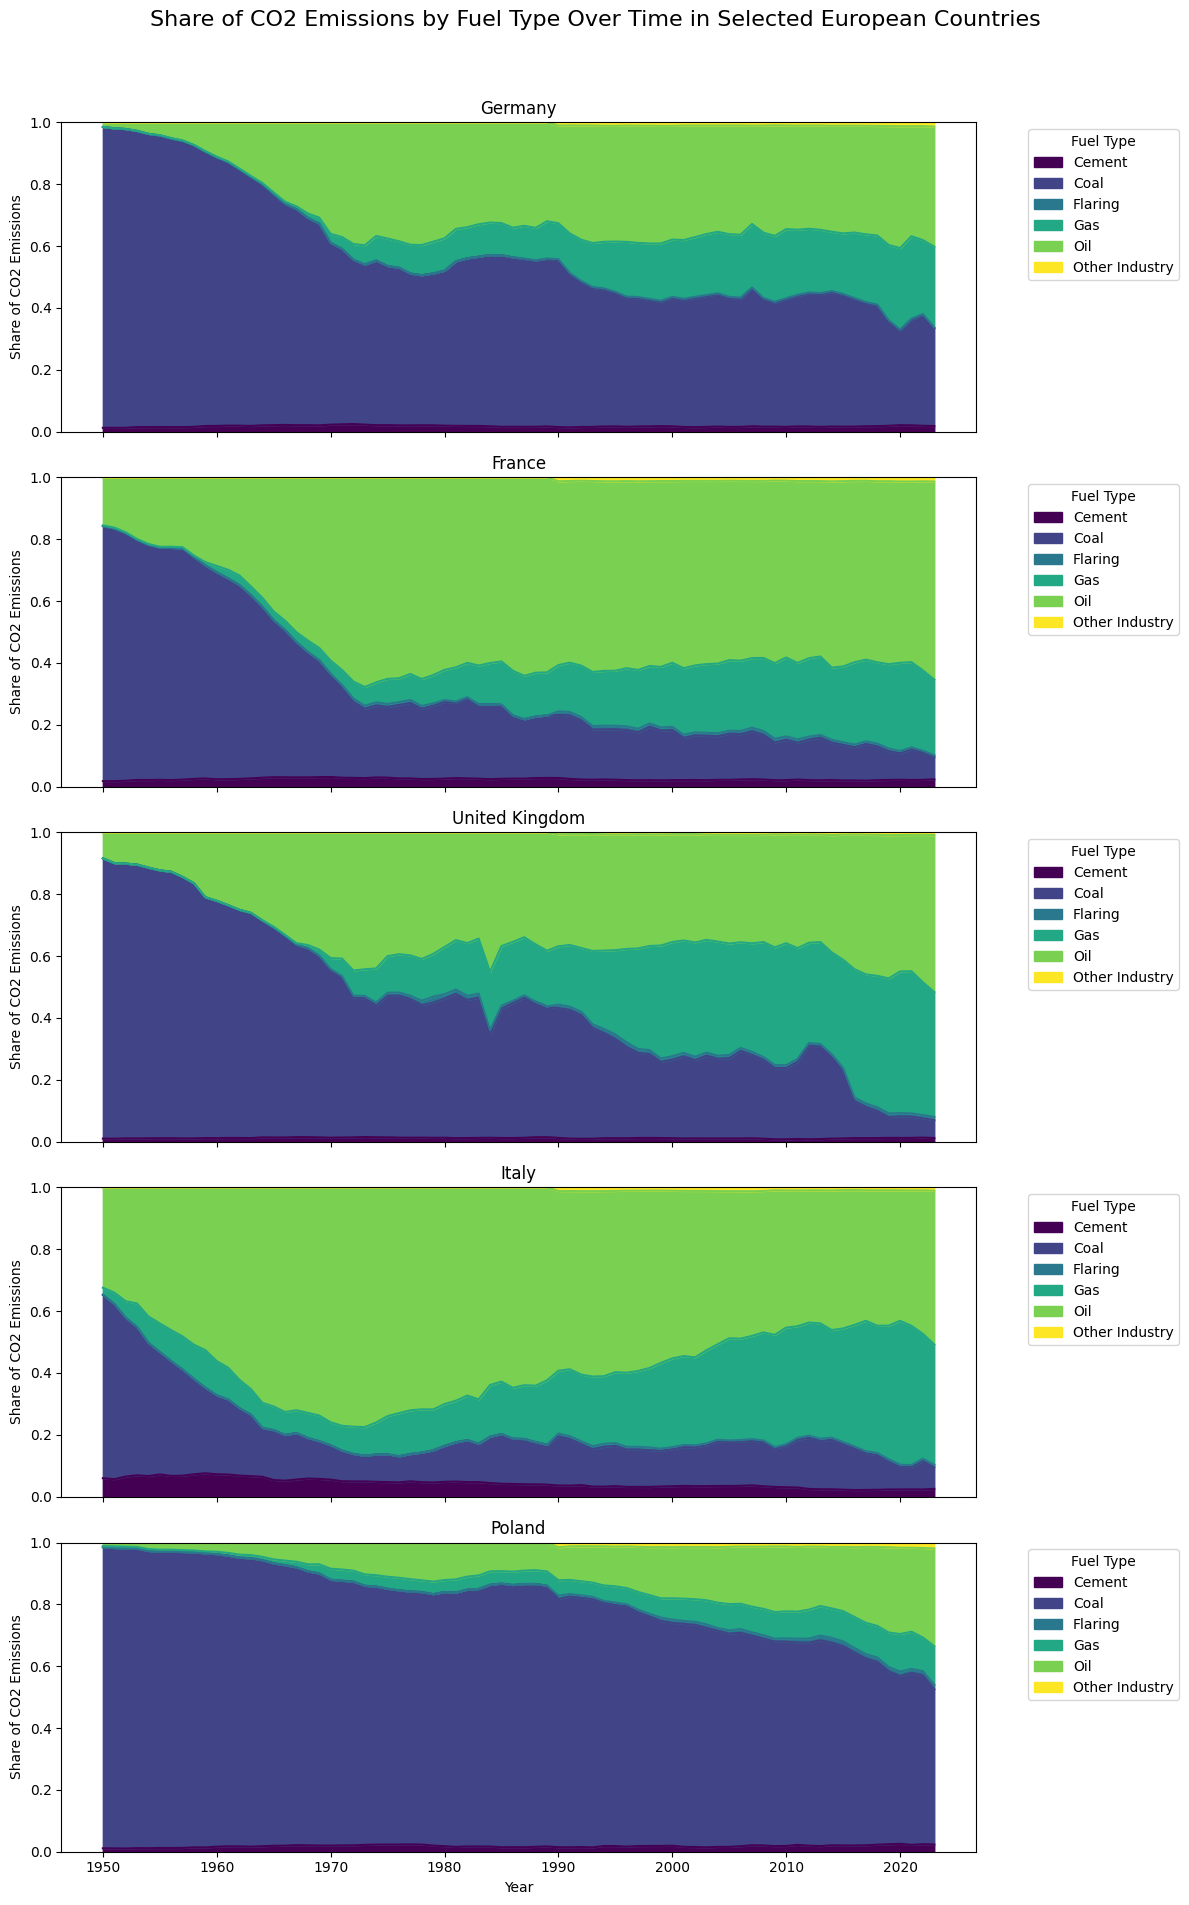

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# List of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and relevant years (e.g., from 1950 onwards for better data availability)
df_co2_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries) & (owid_co2_data_df['year'] >= 1950)].copy()

# Select relevant CO2 emission columns by fuel type
co2_fuel_cols = ['country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']
df_co2_fuel = df_co2_europe[co2_fuel_cols].copy()

# Fill NaN values with 0 for CO2 fuel columns before melting
for col in ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']:
    df_co2_fuel[col] = df_co2_fuel[col].fillna(0)

# Melt the DataFrame to have fuel types as a single column
df_co2_fuel_melted = df_co2_fuel.melt(id_vars=['country', 'year'],
                                      var_name='Fuel Type',
                                      value_name='CO2 Emissions')

# Rename fuel type categories for better readability
df_co2_fuel_melted['Fuel Type'] = df_co2_fuel_melted['Fuel Type'].replace({
    'coal_co2': 'Coal',
    'oil_co2': 'Oil',
    'gas_co2': 'Gas',
    'cement_co2': 'Cement',
    'flaring_co2': 'Flaring',
    'other_industry_co2': 'Other Industry'
})

# Select a few key countries to visualize to avoid too much clutter
selected_countries_v3 = ['Germany', 'France', 'United Kingdom', 'Italy', 'Poland']
df_co2_fuel_selected = df_co2_fuel_melted[df_co2_fuel_melted['country'].isin(selected_countries_v3)]

# Calculate the total emissions for normalization within each country and year
df_co2_fuel_selected['Total Emissions'] = df_co2_fuel_selected.groupby(['country', 'year'])['CO2 Emissions'].transform('sum')
df_co2_fuel_selected['Share'] = df_co2_fuel_selected['CO2 Emissions'] / df_co2_fuel_selected['Total Emissions']

# Plotting with Matplotlib and Seaborn
fig, axes = plt.subplots(len(selected_countries_v3), 1, figsize=(12, 4 * len(selected_countries_v3)), sharex=True)
fig.suptitle('Share of CO2 Emissions by Fuel Type Over Time in Selected European Countries', fontsize=16)

for i, country in enumerate(selected_countries_v3):
    ax = axes[i]
    country_data = df_co2_fuel_selected[df_co2_fuel_selected['country'] == country]

    # Pivot for stacked area plot
    pivot_data = country_data.pivot(index='year', columns='Fuel Type', values='Share').fillna(0)
    pivot_data.plot.area(ax=ax, stacked=True, cmap='viridis')

    ax.set_title(country)
    ax.set_ylabel('Share of CO2 Emissions')
    ax.set_xlabel('Year')
    ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim(0, 1) # Ensure y-axis is from 0 to 1 for share

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [7]:
import pandas as pd
import plotly.express as px

# Load the dataset
data2_df = pd.read_csv('data2.csv', skiprows=8)

# List of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for relevant data
df_renewables_v6 = data2_df[
    (data2_df['Balance'] == 'Net Electricity Production') &
    (data2_df['Unit'] == 'GWh') &
    (data2_df['Country'].isin(european_countries))
].copy()

# Convert 'Time' to datetime objects
# Handle potential errors during conversion by coercing invalid dates to NaT
df_renewables_v6['Date_Parsed'] = pd.to_datetime(df_renewables_v6['Time'], format='%B %Y', errors='coerce')

# Drop rows where Date_Parsed is NaT due to parsing errors
df_renewables_v6.dropna(subset=['Date_Parsed'], inplace=True)

# Filter for relevant renewable product types
renewable_products = ['Hydro', 'Solar', 'Wind', 'Biofuels', 'Geothermal', 'Other renewables']
df_renewables_v6_filtered = df_renewables_v6[df_renewables_v6['Product'].isin(renewable_products)]

# Aggregate total generation by Date_Parsed and Product across all European countries
df_renewables_total_europe = df_renewables_v6_filtered.groupby(['Date_Parsed', 'Product'])['Value'].sum().reset_index()

# Sort by Date_Parsed for proper area chart display
df_renewables_total_europe = df_renewables_total_europe.sort_values(by='Date_Parsed')

# Create the stacked area chart with Plotly Express
fig = px.area(df_renewables_total_europe,
              x='Date_Parsed',
              y='Value',
              color='Product',
              title='Share of Renewable Energy Sources in European Electricity Production',
              labels={'Date_Parsed': 'Date', 'Value': 'Electricity Generation (GWh)', 'Product': 'Renewable Source'},
              line_group='Product', # Ensures proper stacking for different products
              # For normalized stack, use groupnorm
              groupnorm='fraction' # To show share (normalized stack)
             )

fig.update_layout(yaxis_tickformat=".0%") # Format y-axis as percentage
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Share of Renewable Generation')

fig.show()

In [8]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Data inlezen en filteren
df = (
    pd.read_csv("data2.csv", skiprows=8)
      .query("Balance=='Net Electricity Production' and Product=='Electricity' and Time=='March 2025'")
      .loc[lambda d: d['Country'].isin([
          'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czech Republic',
          'Denmark','Estonia','Finland','France','Germany','Greece',
          'Hungary','Ireland','Italy','Latvia','Lithuania','Luxembourg',
          'Malta','Netherlands','Poland','Portugal','Romania','Slovakia',
          'Slovenia','Spain','Sweden'
      ])]
      .assign(
          gwh=lambda d: d['Value'].round(1),
          iso_a3=lambda d: d['Country'].map({
              'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV',
              'Cyprus':'CYP','Czech Republic':'CZE','Denmark':'DNK','Estonia':'EST',
              'Finland':'FIN','France':'FRA','Germany':'DEU','Greece':'GRC',
              'Hungary':'HUN','Ireland':'IRL','Italy':'ITA','Latvia':'LVA',
              'Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
              'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK',
              'Slovenia':'SVN','Spain':'ESP','Sweden':'SWE'
          })
      )
      .drop(columns=['Balance','Product','Time','Value'])
)

# 2. Prepare sorted bar data
df_bar = df.sort_values("gwh", ascending=True)

# 3. Maak een subplot-figuur: 1 rij, 2 kolommen (map + bar)
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.6, 0.4],
    specs=[[{"type": "choropleth"}, {"type": "xy"}]],
    subplot_titles=(
        "Geografische spreiding<br><sup>Groen = laag, Rood = hoog</sup>",
        "Rangorde productie per land"
    )
)

# 4. Voeg choropleth toe
fig.add_trace(
    go.Choropleth(
        locations=df['iso_a3'],
        z=df['gwh'],
        text=df['Country'],
        colorscale="RdYlGn_r",
        zmin=df['gwh'].min(), zmax=df['gwh'].max(),
        colorbar=dict(title="GWh", tickformat=",", len=0.6, y=0.5),
        marker_line_color="white", marker_line_width=0.5,
        hovertemplate="<b>%{text}</b><br>%{z:,.1f} GWh<extra></extra>"
    ),
    row=1, col=1
)

# 5. Voeg horizontale bar chart toe
fig.add_trace(
    go.Bar(
        x=df_bar['gwh'],
        y=df_bar['Country'],
        orientation='h',
        marker=dict(color=df_bar['gwh'], colorscale="RdYlGn_r", cmin=df['gwh'].min(), cmax=df['gwh'].max()),
        hovertemplate="%{y}: %{x:,.1f} GWh<extra></extra>"
    ),
    row=1, col=2
)

# 6. Layout-optimalisaties
fig.update_layout(
    title_text="Energieproductie EU-27 – Maart 2025",
    title_x=0.5,
    template="plotly_white",
    margin=dict(l=10, r=10, t=80, b=20)
)
fig.update_geos(
    scope="europe",
    projection_type="mercator",
    showcountries=False, showsubunits=False,
    lataxis_range=[34, 72], lonaxis_range=[-10, 35]
)

# 7. Toon de figuur
fig.show()




